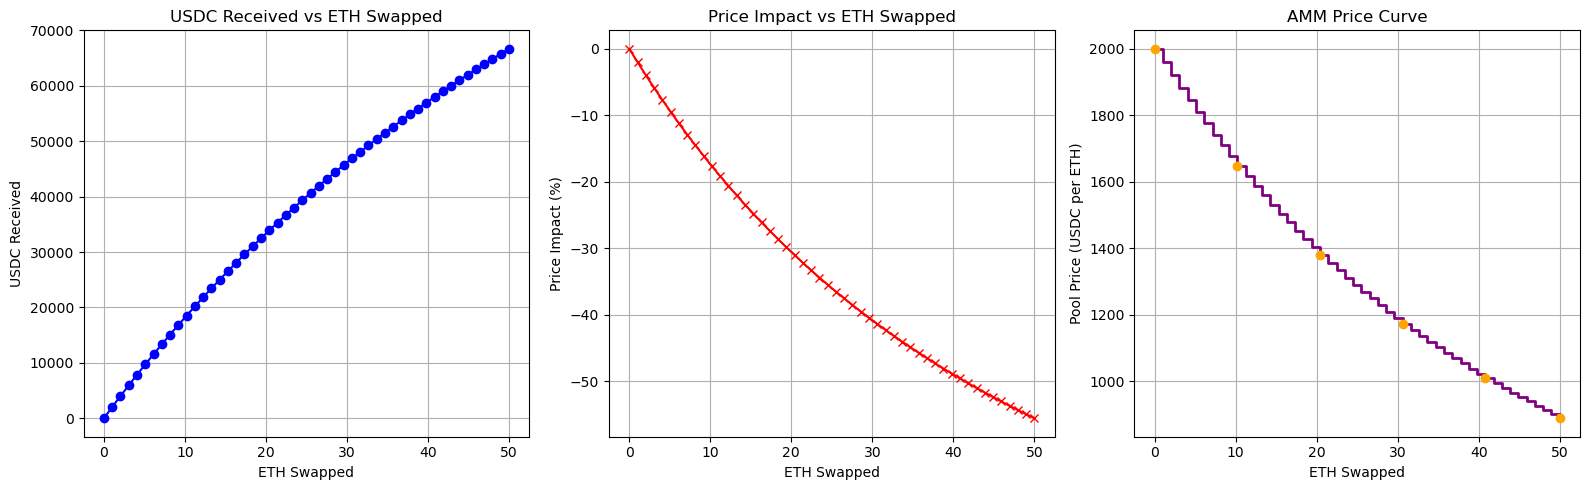

Initial ETH: 100
Initial USDC: 200000

Price before trade: 2000.0 USDC per ETH

Trader swaps: 10 ETH
USDC received: 18181.82
New ETH in pool: 110
New USDC in pool: 181818.18
Price after trade: 1652.89 USDC per ETH
Price impact: -17.36 %


In [1]:
# AMM Price Impact Simulation + Combined Visualization
import matplotlib.pyplot as plt
import numpy as np

# Initial liquidity
eth_pool = 100
usdc_pool = 200000
k = eth_pool * usdc_pool

# Swap sizes to simulate
eth_swaps = np.linspace(0, 50, 50)

# Arrays to store results
usdc_received_list = []
price_after_list = []
price_impact_list = []

# Initial price
price_before = usdc_pool / eth_pool

# Simulation
for eth_swap in eth_swaps:
    new_eth_pool = eth_pool + eth_swap
    new_usdc_pool = k / new_eth_pool
    usdc_received = usdc_pool - new_usdc_pool
    price_after = new_usdc_pool / new_eth_pool
    price_impact = ((price_after - price_before) / price_before) * 100
    
    usdc_received_list.append(usdc_received)
    price_after_list.append(price_after)
    price_impact_list.append(price_impact)

# Combined Visualization
plt.figure(figsize=(16,5))

# Subplot 1: USDC received
plt.subplot(1,3,1)
plt.plot(eth_swaps, usdc_received_list, color='blue', marker='o')
plt.title("USDC Received vs ETH Swapped")
plt.xlabel("ETH Swapped")
plt.ylabel("USDC Received")
plt.grid(True)

# Subplot 2: Price impact
plt.subplot(1,3,2)
plt.plot(eth_swaps, price_impact_list, color='red', marker='x')
plt.title("Price Impact vs ETH Swapped")
plt.xlabel("ETH Swapped")
plt.ylabel("Price Impact (%)")
plt.grid(True)

# Subplot 3: Price curve
plt.subplot(1,3,3)
plt.step(eth_swaps, price_after_list, where='post', color='purple', linewidth=2)
scatter_indices = [0, 10, 20, 30, 40, 49]
plt.scatter(eth_swaps[scatter_indices], [price_after_list[i] for i in scatter_indices], color='orange', zorder=5)
plt.title("AMM Price Curve")
plt.xlabel("ETH Swapped")
plt.ylabel("Pool Price (USDC per ETH)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Example single swap output (10 ETH)
example_swap = 10
new_eth_pool = eth_pool + example_swap
new_usdc_pool = k / new_eth_pool
usdc_received = usdc_pool - new_usdc_pool
price_after = new_usdc_pool / new_eth_pool
price_impact = ((price_after - price_before) / price_before) * 100

print(f"Initial ETH: {eth_pool}")
print(f"Initial USDC: {usdc_pool}")
print(f"\nPrice before trade: {price_before} USDC per ETH")
print(f"\nTrader swaps: {example_swap} ETH")
print(f"USDC received: {round(usdc_received,2)}")
print(f"New ETH in pool: {round(new_eth_pool,2)}")
print(f"New USDC in pool: {round(new_usdc_pool,2)}")
print(f"Price after trade: {round(price_after,2)} USDC per ETH")
print(f"Price impact: {round(price_impact,2)} %")